# 4. Model families, compared under one protocol

Three families, one preprocessing pipeline, one evaluation:

- a **constant baseline** (`DummyClassifier`), which shows what "not learning" scores;
- an **interpretable linear model** (logistic regression);
- a **non-linear model** (random forest).

The goal is not to maximise anything. It is to find out how hard the problem is, what is
reachable without tuning, and what interpretability costs.

Every number below is read from `reports/baselines.csv`, produced by
`uv run python scripts/run_evaluation.py` under 5×5 repeated stratified cross-validation —
the same protocol that produces the shipped model's figures. The first version of this
notebook stated these scores in prose, from a single 90/10 split, and nothing in the
repository produced them.


## Experiment tracking

MLflow is used locally to record parameters, metrics and models across runs.

It is a convenience here, not the source of truth: what this repository publishes comes
from `reports/`, written by a script anyone can re-run. A tracking server that only exists
on the machine that produced the numbers does not make them reproducible.


In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("attrition_serving_baselines")
mlflow.sklearn.autolog()

.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2025/12/17 12:32:16 INFO mlflow.tracking.fluent: Experiment with name 'attrition_serving_baselines' does not exist. Creating a new experiment.


In [ ]:
!mlflow ui --backend-store-uri mlruns --port 5000

## The data

`employees_features.parquet`, from the previous notebook: three HR sources joined, cleaned,
with the derived variables and the coherence checks behind it.

**The target is imbalanced — about 16 % of employees left.** That single fact decides the
metric. Accuracy is not usable: a model that predicts "stays" for everyone scores 0.84 and
finds nobody.


## Target and splitting

The target is `a_quitte_l_entreprise`: 1 if the employee left.

The split here is stratified, so both sides keep the same departure rate, and seeded.

**This split is for the notebook's illustrations only.** What the repository publishes comes
from repeated cross-validation over all 1,470 rows, because a single 10 % test set holds
147 rows and 24 departures — the bootstrap interval on average precision from that set spans
[0.355, 0.726]. The earlier version of this project reported four-decimal figures from it.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

from attrition_serving.config import PATHS, SETTINGS
from attrition_serving.evaluation import (
    evaluate_classifier,
    find_threshold_for_recall,
    plot_precision_recall,
)
from attrition_serving.modeling import make_dummy, make_logreg, make_random_forest
from attrition_serving.preprocessing import FeatureGroups

df = pd.read_parquet(PATHS.data_processed / "employees_features.parquet")

TARGET = "a_quitte_l_entreprise"
assert TARGET in df.columns

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SETTINGS.random_state,
    stratify=y,  # keep the same proportion of classes in train and test sets
)
y.value_counts(normalize=True).round(3)

a_quitte_l_entreprise
0    0.839
1    0.161
Name: proportion, dtype: float64

## Variable types and how each is treated

Variables are grouped by their statistical nature, and each group gets the preprocessing it
needs: continuous, skewed (log-transformed), discrete, binary, nominal categorical, ordinal
categorical.

The nominal/ordinal distinction is the one that matters. One-hot encoding an ordinal
satisfaction scale throws away its order — the model then has to relearn from data that
"low" is below "high", which on 1,470 rows it will do badly.

`reports/feature_encoding.csv` lists every categorical, its encoding, and for the ordinals
the order that was declared.


## Tolerating a changing schema

Only the columns actually present in the frame are kept.

This is defensive, and it has a cost worth naming: a renamed column silently disappears from
the model instead of raising. That is why the column contract is checked elsewhere —
`models/expected_features.json` lists what the model consumes, and the API refuses a payload
that does not carry all of it.


In [2]:
# === Numériques ===
num_cont = [
    "age",
    "augmentation_salaire_precedente",
    "distance_domicile_travail",
    "proba_chgt_experience_par_an",
    "proba_chgt_experience_par_an_adulte",
    "ratio_experience_vie_adulte",
]

num_log = [
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annes_sous_responsable_actuel",
    "annees_depuis_la_derniere_promotion",
]

num_disc = [
    "nombre_participation_pee",
    "nb_formations_suivies",
    "nombre_employee_sous_responsabilite",
    "nombre_experiences_precedentes",
    "nombre_experiences_precedents",
]

# === Binaires ===
bin_cols = ["genre", "heure_supplementaires", "changement_poste"]

# === Nominales ===
cat_nom = ["statut_marital", "departement", "poste", "domaine_etude"]

# === Ordinales ===
cat_ord = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "niveau_hierarchique_poste",
    "niveau_education",
    "frequence_deplacement",
    "evolution_note",
]


# Nettoyage automatique : on ne garde que les colonnes présentes
def keep_existing(cols):
    return [c for c in cols if c in X.columns]


num_cont = keep_existing(num_cont)
num_log = keep_existing(num_log)
num_disc = keep_existing(num_disc)
bin_cols = keep_existing(bin_cols)
cat_nom = keep_existing(cat_nom)
cat_ord = keep_existing(cat_ord)

# Ordres ordinal : par défaut, on prend l’ordre trié (tu pourras le remplacer par un ordre métier explicite)
ord_categories = [sorted(df[c].dropna().unique().tolist()) for c in cat_ord]

groups = FeatureGroups(
    num_cont=num_cont,
    num_log=num_log,
    num_disc=num_disc,
    bin_cols=bin_cols,
    cat_nom=cat_nom,
    cat_ord=cat_ord,
    ord_categories=ord_categories,
)

groups

FeatureGroups(num_cont=['age', 'distance_domicile_travail', 'proba_chgt_experience_par_an', 'proba_chgt_experience_par_an_adulte', 'ratio_experience_vie_adulte'], num_log=['revenu_mensuel', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'annes_sous_responsable_actuel', 'annees_depuis_la_derniere_promotion'], num_disc=['nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'nombre_experiences_precedentes'], bin_cols=['genre', 'heure_supplementaires', 'changement_poste'], cat_nom=['statut_marital', 'departement', 'poste', 'domaine_etude'], cat_ord=['satisfaction_employee_environnement', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_precedente', 'note_evaluation_actuelle', 'niveau_hierarchique_poste', 'niveau_education', 'frequence_deplacement', 'evolution_note'], ord_categories=[[1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2,

## One pipeline, preprocessing included

Preprocessing and model live in a single scikit-learn `Pipeline`.

The reason is leakage. An imputer or a scaler fitted before the split learns from the test
rows: the median it subtracts was computed with them in it. Inside a pipeline, every fold
refits the whole chain on its own training data, and the leak is impossible rather than
merely avoided.


## What each model is for

- **DummyClassifier** — the floor. It predicts the majority class and shows what accuracy is
  worth on a 16 % problem.
- **Logistic regression, `class_weight="balanced"`** — linear and readable, coefficient by
  coefficient. The balancing is what makes it usable on this imbalance, and it is also why
  its raw output is not a probability; see the calibration section of the README.
- **Random forest, `class_weight="balanced"`** — the non-linear counter-expert. If
  interactions matter, it should find them.


In [3]:
models = {
    "Dummy_most_frequent": make_dummy(groups),
    "LogReg_balanced": make_logreg(groups),
    "RandomForest_balanced": make_random_forest(groups),
}

results = {}
for name, model in models.items():
    res = evaluate_classifier(model, X_train, y_train, X_test, y_test, threshold=0.5)
    results[name] = res
    print("\n" + "=" * 80)
    print(name)
    print("AP train:", res["train_ap"], " | AP test:", res["test_ap"])
    print("ROC AUC train:", res["train_roc_auc"], " | ROC AUC test:", res["test_roc_auc"])
    print("\nTest report:\n", res["test_report"])
    print("Test confusion matrix:\n", res["test_cm"])

.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarni


Dummy_most_frequent
AP train: 0.16156462585034015  | AP test: 0.1598639455782313
ROC AUC train: 0.5  | ROC AUC test: 0.5

Test report:
               precision    recall  f1-score   support

           0      0.840     1.000     0.913       247
           1      0.000     0.000     0.000        47

    accuracy                          0.840       294
   macro avg      0.420     0.500     0.457       294
weighted avg      0.706     0.840     0.767       294

Test confusion matrix:
 [[247   0]
 [ 47   0]]

LogReg_balanced
AP train: 0.6845424330591589  | AP test: 0.5497156370691155
ROC AUC train: 0.8683516600832711  | ROC AUC test: 0.7978292703936601

Test report:
               precision    recall  f1-score   support

           0      0.925     0.798     0.857       247
           1      0.383     0.660     0.484        47

    accuracy                          0.776       294
   macro avg      0.654     0.729     0.670       294
weighted avg      0.838     0.776     0.797       294



## Metrics

Accuracy is excluded on purpose: at a 16 % base rate a constant "stays" scores 0.84 and
detects nothing.

What is reported instead:

- **average precision** (PR-AUC), which is sensitive to performance on the rare class;
- **precision and recall** at the operating threshold;
- **ROC AUC**, as a ranking measure that does not depend on the threshold;
- **the spread across folds**, because a single number from 24 events is not a measurement.


## Reading the comparison

The table above comes from `reports/baselines.csv`. Three things in it are worth stopping on.

**The dummy's recall is 1.000, and it means nothing.** Its scores are constant, so forcing a
recall target onto it produces the only threshold that reaches the target: alert on
everyone. Its average precision is 0.161 — exactly the base rate — and its ROC AUC is 0.500.
Those two are what say it has learned nothing.

**The forest is worse than the linear model**, 0.531 against 0.607 average precision, with a
wider spread. On 1,470 rows and 32 features, the interactions it can find are outnumbered by
the ones it invents.

**The logistic regression wins on every measure that matters here** and is the one that can
be read coefficient by coefficient, which on an HR decision is not a tie-breaker but a
requirement.

Good separation is not causation. What follows identifies a candidate model, not a set of
levers to pull.


## Choosing the decision threshold

0.5 is a default, not a decision, and on an imbalanced problem it is rarely the right one.

The two errors are not symmetric and not comparable in the abstract: a missed departure is a
replacement to fund, a false alert is a conversation held for nothing. What the repository
does with that is in the README — the threshold it ships comes from an expected-cost curve
over a stated ratio between the two, published in `reports/cost_curve.csv`, rather than from
a recall target chosen because it sounded reasonable.

The threshold shown in this notebook is illustrative and read on the raw score scale. The
shipped one is read on the calibrated scale and is not comparable to it.


0.3297227774868942

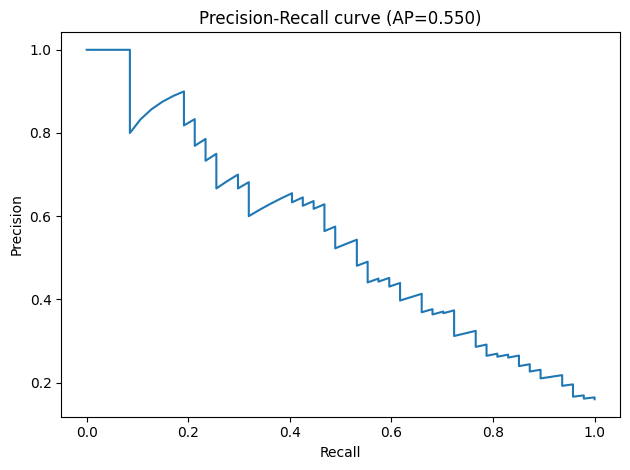

In [5]:
best_name = "LogReg_balanced"  # ou RF si meilleur
p_test = results[best_name]["p_test"]

plot_precision_recall(y_test, p_test)

thr = find_threshold_for_recall(y_test, p_test, target_recall=0.80)
thr

## At the operating threshold

Recall on the departure class rises, precision falls, and accuracy stops being informative.

That trade is the whole point, and its price is in `reports/cost_curve.csv`: at the shipped
ratio the service alerts on about 37 % of employees to catch 78 % of departures. Whether
that is a usable ratio is an operational question, and the curve is there so it can be
answered rather than assumed.


In [6]:
res_thr = evaluate_classifier(models[best_name], X_train, y_train, X_test, y_test, threshold=thr)
print(res_thr["test_report"])
print(res_thr["test_cm"])

              precision    recall  f1-score   support

           0      0.935     0.583     0.718       247
           1      0.264     0.787     0.396        47

    accuracy                          0.616       294
   macro avg      0.600     0.685     0.557       294
weighted avg      0.828     0.616     0.667       294

[[144 103]
 [ 10  37]]


.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## What the baselines settled

- The dummy fixes the floor: 0.161 average precision, 0.500 ROC AUC.
- The logistic regression is the candidate: 0.607 ± 0.058, and readable.
- The forest does not beat it here, and overfits: 0.531 ± 0.057.

Average precision is the informative metric on this imbalance, and the fold spread is why it
is always reported with one.

What comes next: hyper-parameter search under the same cross-validation, then permutation
importance and SHAP on the retained model — and the calibration, cost curve and subgroup
analysis that the README publishes.
